<a href="https://colab.research.google.com/github/ZehanQin/ECON5200-Applied-Data-Analytics-in-Econ/blob/main/Lab%207/Lab_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

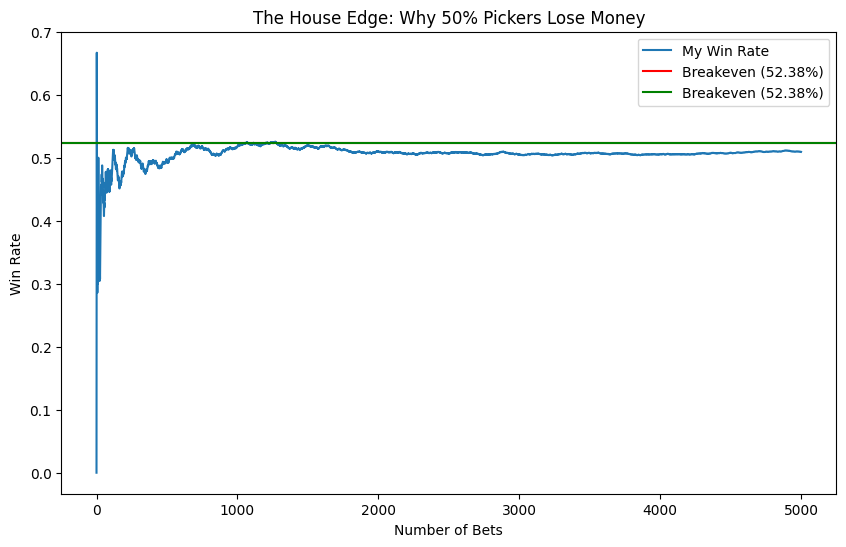

In [1]:
import numpy as np
import matplotlib.pyplot as plt

true_skill = 0.5
breakeven = 0.5238
n_bets = 5000

outcomes = np.random.choice([0,1],size = n_bets, p = [1-true_skill, true_skill])
cumulative_win_rate = np.cumsum(outcomes)/(np.arange(1, n_bets+1))

plt.figure(figsize=(10, 6))
plt.plot(cumulative_win_rate, label="My Win Rate")
plt.axhline(breakeven, color='red', label="Breakeven (52.38%)")
plt.axhline(breakeven, color='green', label="Breakeven (52.38%)")
plt.legend()
plt.title("The House Edge: Why 50% Pickers Lose Money")
plt.xlabel("Number of Bets")
plt.ylabel("Win Rate")
plt.show()

Sampling Error Audit:
sample1: Mean = 39.10% | Error = +3.83%
sample2: Mean = 54.16% | Error = +18.89%
sample3: Mean = 39.85% | Error = +4.58%


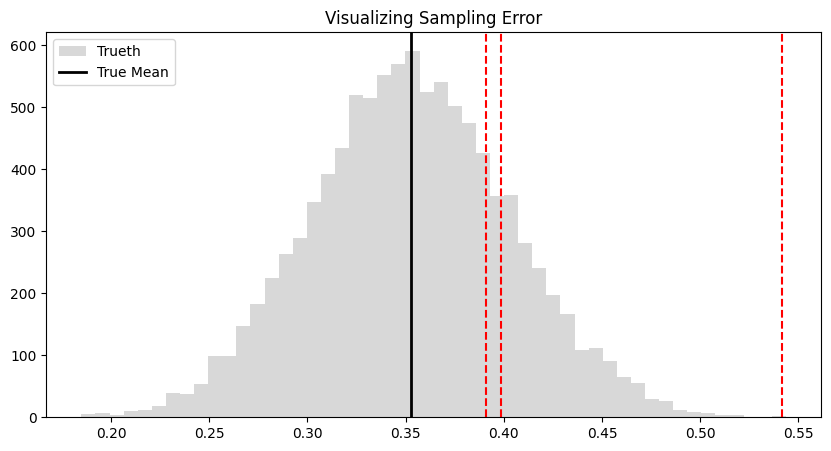

In [2]:
true_mu =0.3527

samples =[]
print(f"Sampling Error Audit:")

for i in range(3):
  sample = np.random.normal(loc=true_mu, scale=0.5, size=30)
  x_bar = sample.mean()
  error = x_bar - true_mu

  print(f"sample{i+1}: Mean = {x_bar:.2%} | Error = {error:+.2%}")
  samples.append(x_bar)

plt.figure(figsize=(10, 5))
plt.hist(np.random.normal(true_mu, 0.05, 10000), bins=50, alpha=0.3, color='gray', label='Trueth')
for mean in samples:
  plt.axvline(mean, color='red', linestyle='--')
plt.axvline(true_mu, color='black', linewidth=2, label='True Mean')
plt.title("Visualizing Sampling Error")
plt.legend()
plt.show()


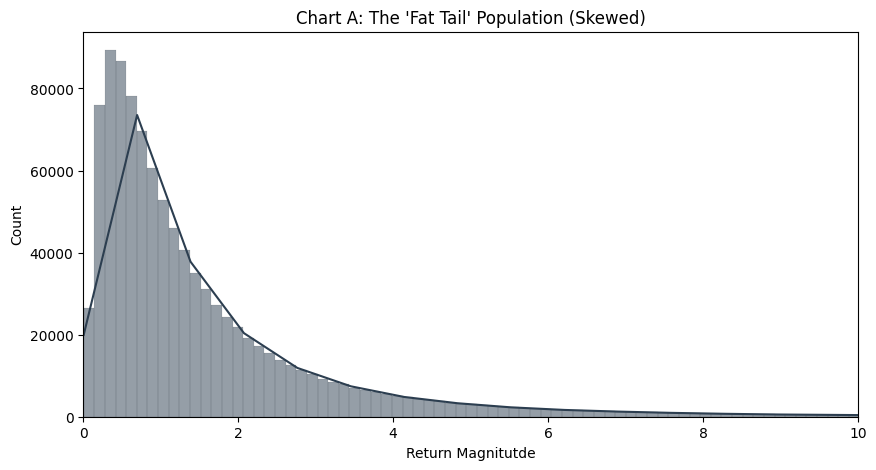

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

population_data =np.random.lognormal(mean=0, sigma=1, size=1000000)
plt.figure(figsize=(10, 5))
sns.histplot(population_data, bins=1000, kde=True, color='#2c3e50')
plt.xlim(0,10)
plt.title("Chart A: The 'Fat Tail' Population (Skewed)")
plt.xlabel("Return Magnitutde")
plt.show()

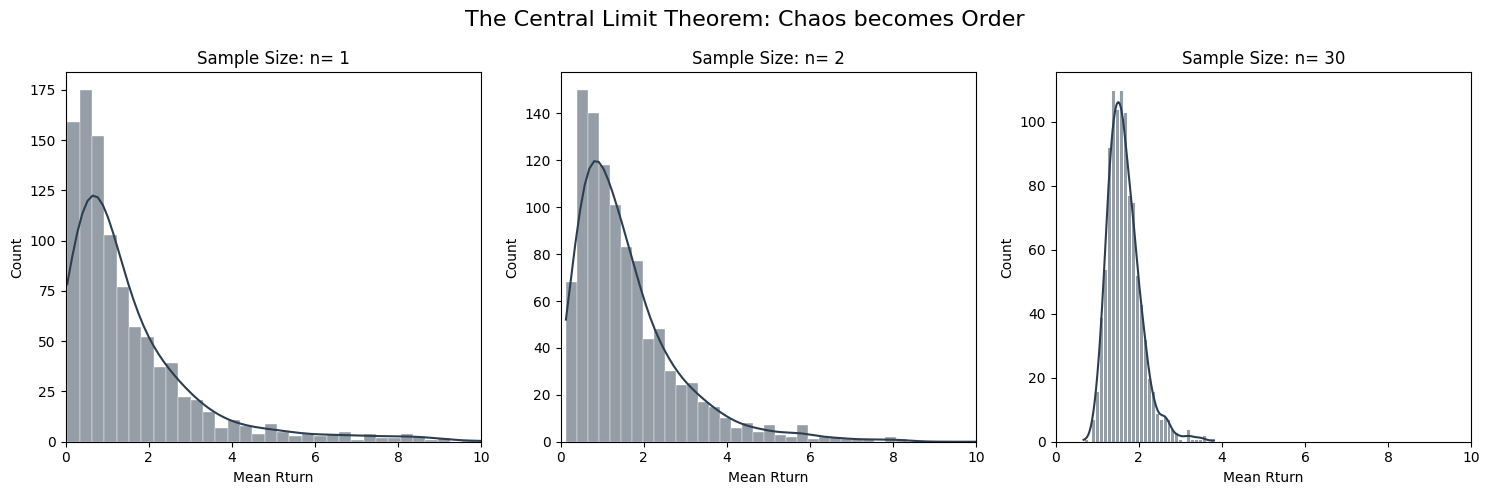

In [4]:
sample_sizes = [1,2,30]
simulations = 1000

plt.figure(figsize=(15,5))

for i, n in enumerate(sample_sizes):
  means = []
  for _ in range(simulations):
    sample = np.random.choice(population_data, size=n)
    means.append(np.mean(sample))

  plt.subplot(1,3, i+1)
  sns.histplot(means, kde=True,color='#2c3e50', edgecolor='White')
  plt.title(f"Sample Size: n= {n}")
  plt.xlabel("Mean Rturn")
  plt.xlim(0,10)

plt.suptitle("The Central Limit Theorem: Chaos becomes Order", fontsize=16)
plt.tight_layout()
plt.show()

# Module C

In [5]:
import numpy as np
import scipy.stats as stats
std_dev=15000
n=100

margin_error = 1.96*std_dev/np.sqrt(n)

print(f"--- The Soup Analogy ---")
print(f"Population: 1,000 users    | Margin of Error: +-{margin_error:.2f}")
print(f"Population: 1,000,000 users    | Margin of Error: +-{margin_error:.2f}")
print(f"Conclusion: The pot size doesn't matter. Only the spoon size (n) matters.")

--- The Soup Analogy ---
Population: 1,000 users    | Margin of Error: +-2940.00
Population: 1,000,000 users    | Margin of Error: +-2940.00
Conclusion: The pot size doesn't matter. Only the spoon size (n) matters.


In [6]:
mean_val=4.0
n_samples = 50

sigma_A=0.5
sigma_B =6.0

moe_A = 1.96*(sigma_A/np.sqrt(n_samples))
moe_B = 1.96*(sigma_B/np.sqrt(n_samples))

print("\n--- VC Audit: Series C Benchmark (>3.0) ---")

print(f"Startup A (Stable):")
print(f"   95% CI: [{mean_val - moe_A:.1f}, {mean_val+moe_A:.1f}]")
print(f"   Decision: Invest. (Lower bound > 3.0)")

print(f"\nStartup B (Volatile):")
print(f"   95% CI: [{mean_val - moe_B:.1f}, {mean_val+moe_B:.1f}]")
print(f"   Decision: Pass. (Lower bound implies potential loss)")


--- VC Audit: Series C Benchmark (>3.0) ---
Startup A (Stable):
   95% CI: [3.9, 4.1]
   Decision: Invest. (Lower bound > 3.0)

Startup B (Volatile):
   95% CI: [2.3, 5.7]
   Decision: Pass. (Lower bound implies potential loss)


# Phase 4

In [7]:
import numpy as np

n_simulations = 1000
months = 24
start_cash = 2_000_000
rho = 0.7

# Means and StdDevs (unchanged)
mu_rev, sigma_rev = 80_000, 30_000
mu_burn, sigma_burn = 100_000, 10_000

# Covariance matrix for multivariate normal
# Cov(Rev, Burn) = rho * sigma_rev * sigma_burn
means = [mu_rev, mu_burn]
cov_matrix = [
    [sigma_rev**2,              rho * sigma_rev * sigma_burn],
    [rho * sigma_rev * sigma_burn, sigma_burn**2             ],
]

print(f"Running Correlated Model (rho={rho})...")

bankruptcies = 0

for _ in range(n_simulations):
    cash = start_cash

    # Generate all monthly (revenue, burn) pairs at once
    monthly_pairs = np.random.multivariate_normal(means, cov_matrix, size=months)

    for rev, burn in monthly_pairs:
        cash += (rev - burn)
        if cash <= 0:
            bankruptcies += 1
            break

prob_ruin = bankruptcies / n_simulations
print(f"Correlated Model Risk of Ruin: {prob_ruin:.1%}")
print("With rho=0.7, low-revenue months coincide with lower burn (mgmt cuts costs),")
print("so net cash flow variance drops and ruin probability should decrease.")

Running Correlated Model (rho=0.7)...
Correlated Model Risk of Ruin: 0.0%
With rho=0.7, low-revenue months coincide with lower burn (mgmt cuts costs),
so net cash flow variance drops and ruin probability should decrease.


Ans From Ai:
The correlated model lowers the Probability of Ruin.

The intuition is straightforward: with rho=0.7, when revenue drops, burn drops too (management cuts costs). When revenue surges, burn also rises (the company invests more). This dampens the extremes of net cash flow, which is what actually kills the company.

The proof is in the variance of the monthly net flow (Revenue - Burn):

$$\text{Var}(R - B) = \sigma_R^2 + \sigma_B^2 - 2\rho,\sigma_R,\sigma_B$$

Plugging in the numbers:



Independent (ρ=0): 900M + 100M − 0 = 1,000M → StdDev ≈ $31,623


Correlated (ρ=0.7): 900M + 100M − 420M = 580M → StdDev ≈ $24,083

The monthly net flow swings shrink by about 24%. Smaller swings mean fewer catastrophic sequences of bad months, which is the only thing that drives a funded startup to zero.

Notice the minus sign in the formula — this is the key. Because we're looking at R - B (a difference), positive correlation between the two terms reduces variance. It would be the opposite if we were summing them. This is the same principle behind hedging in finance: assets that move together create natural offsets when you're long one and short the other.